WILL YOU SURVIVE THE TITANIC?

In [1]:
import pandas as pd

df = pd.read_csv(r"LogisticRegression\Will_you_survive_titanic\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- **PassengerId**: Unique identifier for each passenger (row ID, no real meaning).  
- **Survived**: Target variable indicating if the passenger survived (1) or not (0).  
- **Pclass**: Passenger’s travel class (1st, 2nd, 3rd) reflecting ticket price and comfort.  
- **Name**: Full name of the passenger including title (e.g., Mr., Mrs., Miss).  
- **Sex**: Passenger’s gender (male or female).  
- **Age**: Passenger’s age in years (can be fractional and has missing values).  
- **SibSp**: Number of siblings and spouses traveling with the passenger.  
- **Parch**: Number of parents and children traveling with the passenger.  
- **Ticket**: Ticket number/code assigned to the booking.  
- **Fare**: Price paid for the ticket.  
- **Cabin**: Cabin code where the passenger stayed (many values missing).  
- **Embarked**: Port where the passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton).

In [3]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.drop(columns = ["PassengerId", "Name", "Ticket", "Cabin"], inplace = True)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
df["Embarked"].value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [7]:
df["SibSp"].value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

In [8]:
df["Parch"].value_counts()

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


detecting outliers (if any) and labelEncoding categorical columns

In [10]:
from sklearn.preprocessing import LabelEncoder

to_encode = ["Sex", "Embarked"]

for col in to_encode:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])
    encoded = le

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [12]:
df["Embarked"].value_counts()

2    646
0    168
1     77
Name: Embarked, dtype: int64

in SEX (1 = MALE and 0 = Female)

in EMBARKED (S = 2, C = 0, Q = 1)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 48.9 KB


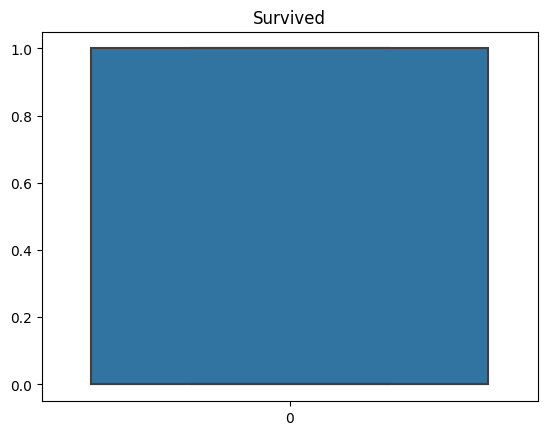

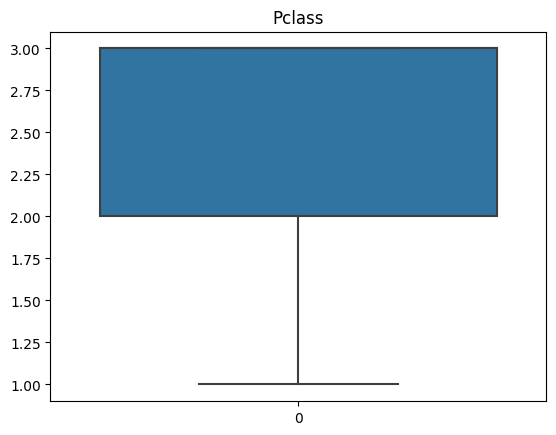

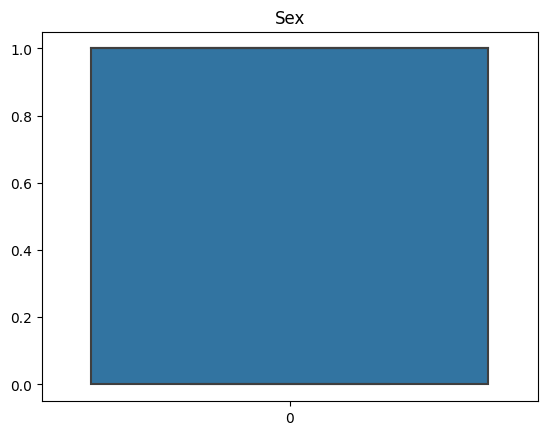

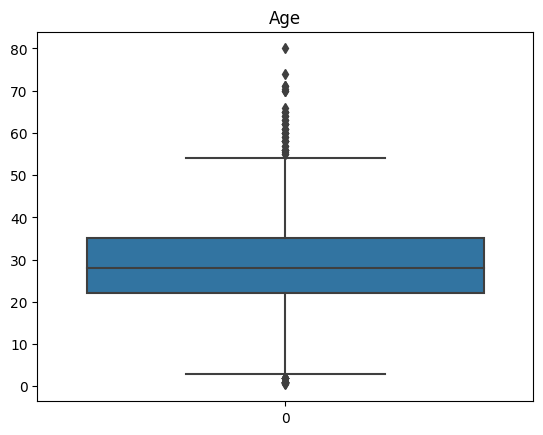

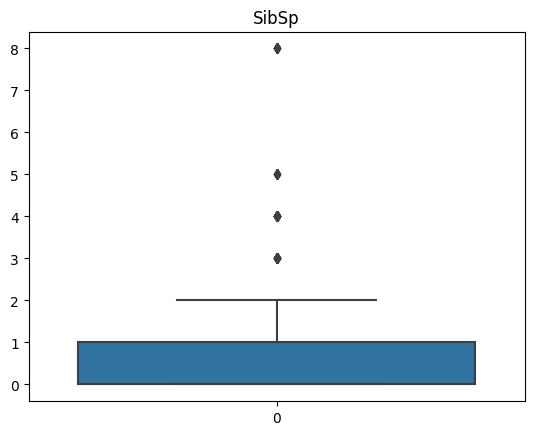

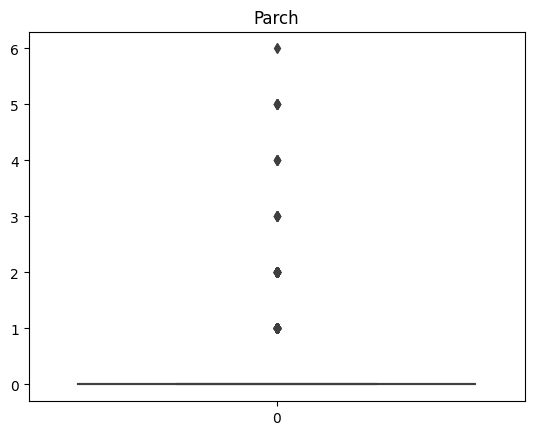

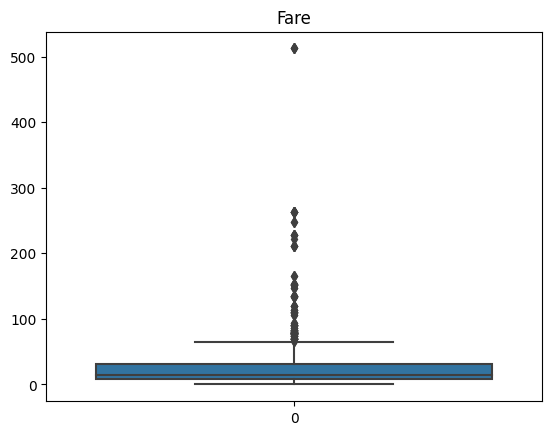

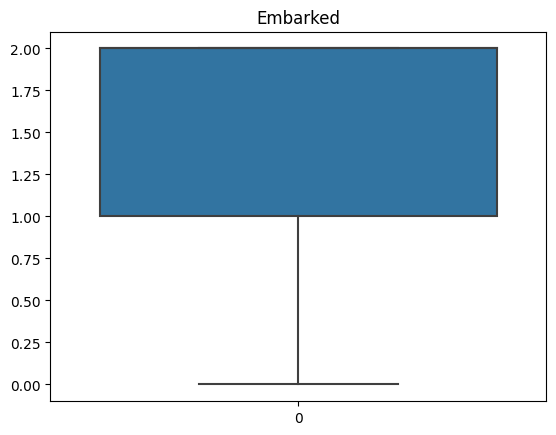

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 48.9 KB


training the model

In [16]:
all_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dtc = DecisionTreeClassifier(max_depth = 3, random_state = 42)

preprocess = ColumnTransformer(transformers = [('pass', "passthrough", all_features)], remainder = "drop")

model = Pipeline(steps = [('pre', preprocess), ('dtc', dtc)])

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ["Survived"])
y = df["Survived"]

[X_train, X_test, y_train, y_test] = train_test_split(X,y, test_size = 0.2, random_state = 42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import numpy as np

cm = confusion_matrix(y_test, y_pred)
asc = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"confusion_matrix : \n{cm}\naccuracy_score : {asc}\nclassification_report : \n{cr}")

confusion_matrix : 
[[92 13]
 [23 51]]
accuracy_score : 0.7988826815642458
classification_report : 
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

